# House Price Prediction
Professional ML workflow using the provided housing dataset.

In [1]:
# Install once if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Dataset

In [6]:
train_path = "data/train.csv"   # Change if needed
test_path = "data/test.csv"    # Change if needed

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

df = pd.concat([train_df, test_df], ignore_index=True)

df.head()

,property_id,city,locality,locality_tier,property_type,bhk,bathrooms,balconies,built_up_area,carpet_area,...,power_backup,lift_available,maintenance_fee_monthly,distance_to_city_center_km,distance_to_metro_km,nearby_schools,nearby_hospitals,transaction_type,price_in_lakhs,price_category
0,PROP-045251,Mumbai,Bandra,Premium,Studio,1,1,0,526,454,...,1,0,5388,10.1,8.1,2,5,Resale,69.01,Low
1,PROP-037124,Bangalore,Whitefield,Standard,Villa,3,3,1,1833,1563,...,1,1,5916,11.2,2.6,2,1,Resale,153.72,Low
2,PROP-017296,Mumbai,Powai,Standard,Independent House,3,3,1,1732,1452,...,0,1,3166,10.3,2.4,3,2,New,122.76,Low
3,PROP-031278,Bangalore,Electronic City,Standard,Studio,1,2,0,447,362,...,1,1,1776,10.0,2.4,0,1,Resale,20.80,Low
4,PROP-034818,Mumbai,Thane,Affordable,Villa,4,5,0,2276,1944,...,1,0,4667,23.5,0.6,3,0,Resale,177.95,Low


In [14]:
print(df.columns.tolist())

['property_id', 'city', 'locality', 'locality_tier', 'property_type', 'bhk', 'bathrooms', 'balconies', 'built_up_area', 'carpet_area', 'floor_number', 'total_floors', 'floor_category', 'facing', 'furnishing_status', 'property_age', 'parking_spaces', 'security_score', 'gym_available', 'swimming_pool', 'power_backup', 'lift_available', 'maintenance_fee_monthly', 'distance_to_city_center_km', 'distance_to_metro_km', 'nearby_schools', 'nearby_hospitals', 'transaction_type', 'price_in_lakhs', 'price_category']


## Basic Exploration

In [7]:
print(df.shape)
display(df.info())
display(df.describe(include='all').T)

print("\nMissing Values")
display(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nDuplicate Rows:", df.duplicated().sum())

(42500, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42500 entries, 0 to 42499
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_id                 42500 non-null  object 
 1   city                        42500 non-null  object 
 2   locality                    42500 non-null  object 
 3   locality_tier               42500 non-null  object 
 4   property_type               42500 non-null  object 
 5   bhk                         42500 non-null  int64  
 6   bathrooms                   42500 non-null  int64  
 7   balconies                   42500 non-null  int64  
 8   built_up_area               42500 non-null  int64  
 9   carpet_area                 42500 non-null  int64  
 10  floor_number                42500 non-null  int64  
 11  total_floors                42500 non-null  int64  
 12  floor_category              42500 non-null  object 
 13  facing             

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
property_id,42500,42500,PROP-045251,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,42500,4,Bangalore,12298,NaN,NaN,NaN,NaN,NaN,NaN,NaN
locality,42500,20,Bandra,3048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
locality_tier,42500,3,Standard,19932,NaN,NaN,NaN,NaN,NaN,NaN,NaN
property_type,42500,6,Apartment,17053,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bhk,42500.0,NaN,NaN,NaN,3.151906,1.215476,1.0,2.0,3.0,4.0,5.0
bathrooms,42500.0,NaN,NaN,NaN,3.364941,1.330047,1.0,2.0,3.0,4.0,6.0
balconies,42500.0,NaN,NaN,NaN,1.687529,1.234808,0.0,1.0,2.0,3.0,4.0
built_up_area,42500.0,NaN,NaN,NaN,1573.120447,670.073735,300.0,1046.0,1586.0,2131.25,3056.0
carpet_area,42500.0,NaN,NaN,NaN,1321.430659,564.079721,240.0,878.0,1328.5,1785.0,2666.0



Missing Values


property_id                   0
city                          0
price_in_lakhs                0
transaction_type              0
nearby_hospitals              0
nearby_schools                0
distance_to_metro_km          0
distance_to_city_center_km    0
maintenance_fee_monthly       0
lift_available                0
power_backup                  0
swimming_pool                 0
gym_available                 0
security_score                0
parking_spaces                0
property_age                  0
furnishing_status             0
facing                        0
floor_category                0
total_floors                  0
dtype: int64


Duplicate Rows: 0


## Exploratory Data Analysis

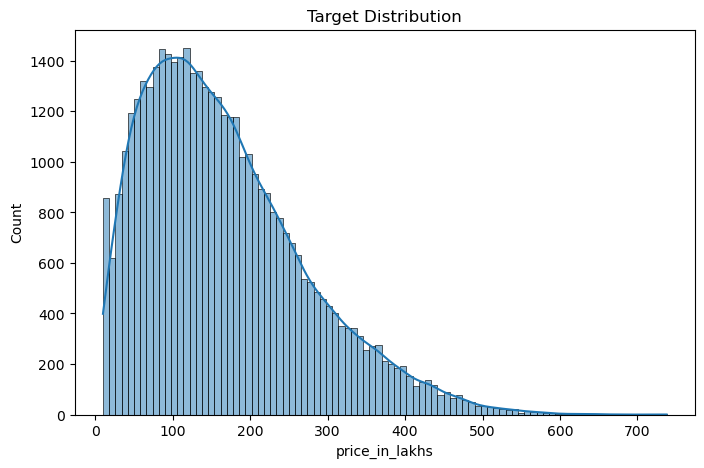

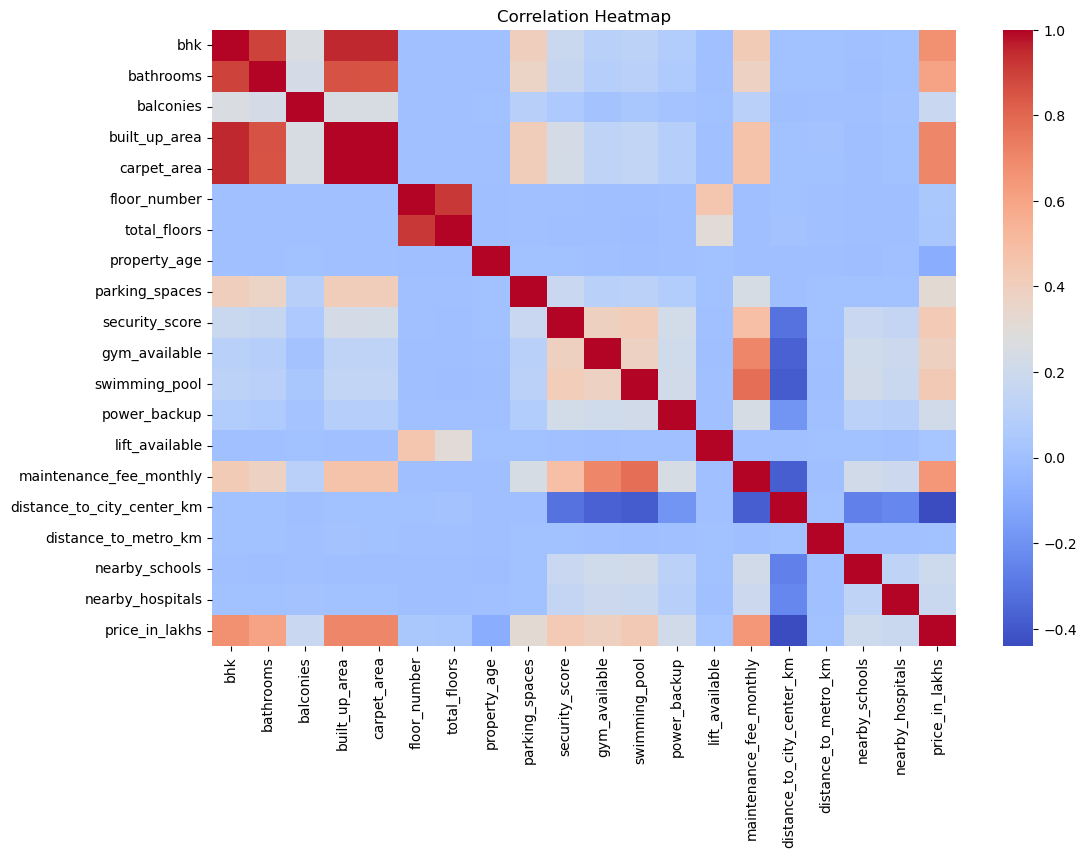

In [8]:
target = "price_in_lakhs"

plt.figure(figsize=(8,5))
sns.histplot(df[target], kde=True)
plt.title("Target Distribution")
plt.show()

numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Data Preprocessing

In [9]:
target = "price_in_lakhs"

X = df.drop(columns=[target])
y = df[target]

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

## Model Training

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=20,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

pred = model.predict(X_test)

## Evaluation

In [11]:
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 23.817960823529415
MSE : 1133.365181561353
RMSE: 33.6654894745547
R2  : 0.8945289786474319


## Save Model

In [12]:
joblib.dump(model, "house_price_model.pkl")
print("Model saved successfully.")

Model saved successfully.


## Predict on New Data

In [13]:
sample = X.iloc[[0]].copy()
prediction = model.predict(sample)
print("Predicted Price:", prediction[0])

Predicted Price: 72.81949999999999


# Conclusion

This project predicts house prices using Machine Learning. The workflow includes:
- Data Loading
- Data Exploration
- Data Preprocessing
- Model Training
- Model Evaluation
- Model Saving
- Price Prediction

The trained model can be deployed as a web application using Streamlit.